# <div style="color: #1F3A5F; font-family: Arial; text-align: center; font-weight: bold;">An Explainable Machine Learning-Based Fraud Detection System</div>

<div style="border-radius:10px; border:#1F3A5F solid; padding: 15px; background-color: ##F0E68C ; font-size:100%; text-align:left">

<h3 align="left"><font color= #1F3A5F>Problem Statement</font></h3>
  
- In recent years, there has been a significant increase in the volume of financial transactions due to the expansion of financial institutions and the popularity of web-based e-commerce (Enaifoghe, 2026). 

- Fraudulent transactions have become a growing
problem in online banking, and fraud detection has always
been challenging (Nanduri et al., 2020).

- Along with credit card development, the pattern of credit
card fraud has always been updated. Fraudsters do their
best to make it look legitimate, and credit card fraud has
always been updated.

- They try to learn how fraud detection systems
work and continue to test these systems, making fraud
detection more complicated. 

- Therefore, we are trying to find new ways to improve the performance of the existing methods.  

</div>

# <p style="background-color: #1F3A5F; font-family:calibri; color:white; font-size:140%; font-family:Verdana; text-align:center; border-radius:15px 50px;">1.| Setup and Initialization</p>


# <b><span style='color:#1F3A5F'>1.1 |</span><span style='color:#1F3A5F'> Importing Necessary Libraries</span></b>


In [65]:
pip install noisereduce

Note: you may need to restart the kernel to use updated packages.


In [66]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Core libraries
import numpy as np
import pandas as pd
import os
import re
import itertools
import warnings
warnings.filterwarnings('ignore')

# Image processing
import cv2
from PIL import Image
from pathlib import Path
from skimage import io
from tabulate import tabulate
from sklearn.impute import KNNImputer
from sklearn.utils import shuffle
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.effects
import soundfile as sf
from scipy.signal import butter, sosfilt


# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img
from tensorflow.keras.applications import DenseNet201, ResNet152V2
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, BatchNormalization, Dropout
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    mean_squared_error
)

# Utilities
import shutil
import zipfile

# Audio display
from IPython.display import Audio, display
import librosa
import IPython.display as ipd

import librosa
import librosa.display
import noisereduce as nr
from scipy.signal import butter, sosfilt
import numpy as np
import pandas as pd
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import librosa

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import librosa
import librosa.display
import math
import ast
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


# <p style="background-color: #1F3A5F; font-family:calibri; color:white; font-size:140%; font-family:Verdana; text-align:center; border-radius:15px 50px;">2.| Data Loading</p>

# <b><span style='color:#1F3A5F'>2.1 |</span><span style='color:#1F3A5F'> Loading the Dataset</span></b>

In [67]:
data=pd.read_csv("/kaggle/input/datasets/angelarentsi/financial-dataset/PS_20174392719_1491204439457_log.csv")
data

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [68]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [69]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [70]:
data.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

# <b><span style='color:#1F3A5F'>2.2 |</span><span style='color:#1F3A5F'> Stratify The Dataset</span></b>

In [71]:
# ==========================================================
# SAMPLE ONLY 10% OF NON-FRAUD CASES
# KEEP ALL FRAUD CASES
# ==========================================================

import pandas as pd

print("="*60)
print("Original Dataset")
print("="*60)

overview_before = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Fraud Cases",
        "Non-Fraud Cases"
    ],
    "Value": [
        len(data),
        data.shape[1],
        (data["isFraud"] == 1).sum(),
        (data["isFraud"] == 0).sum()
    ]
})

display(overview_before)

# ----------------------------------------------------------
# Separate Fraud and Non-Fraud Transactions
# ----------------------------------------------------------

fraud = data[data["isFraud"] == 1]
non_fraud = data[data["isFraud"] == 0]

# ----------------------------------------------------------
# Sample ONLY 10% of Non-Fraud Cases
# ----------------------------------------------------------

non_fraud_sample = non_fraud.sample(
    frac=0.10,          # Keep 10% of non-fraud cases
    random_state=42
)

# ----------------------------------------------------------
# Combine with ALL Fraud Cases
# ----------------------------------------------------------

data = pd.concat(
    [fraud, non_fraud_sample],
    ignore_index=True
)

# Shuffle the dataset
data = data.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("="*60)
print("After Sampling 10% of Non-Fraud Cases")
print("="*60)

overview_after = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Fraud Cases",
        "Non-Fraud Cases"
    ],
    "Value": [
        len(data),
        data.shape[1],
        (data["isFraud"] == 1).sum(),
        (data["isFraud"] == 0).sum()
    ]
})

display(overview_after)

Original Dataset


,Metric,Value
0,Rows,6362620
1,Columns,11
2,Fraud Cases,8213
3,Non-Fraud Cases,6354407


After Sampling 10% of Non-Fraud Cases


,Metric,Value
0,Rows,643654
1,Columns,11
2,Fraud Cases,8213
3,Non-Fraud Cases,635441


# <p style="background-color: #1F3A5F; font-family:calibri; color:white; font-size:140%; font-family:Verdana; text-align:center; border-radius:15px 50px;">3.| Data Preprocessing</p>

# <b><span style='color:#1F3A5F'>3.1 |</span><span style='color:#1F3A5F'> Dataset OverView</span></b>

In [72]:
overview = pd.DataFrame({
    "Metric": [
        "Number of Rows",
        "Number of Columns",
        "Duplicate Rows",
        "Missing Values",
        "Memory Usage (MB)"
    ],
    "Value": [
        data.shape[0],
        data.shape[1],
        data.duplicated().sum(),
        data.isnull().sum().sum(),
        round(data.memory_usage(deep=True).sum()/1024**2,2)
    ]
})

print("DATASET OVERVIEW")
display(overview)

DATASET OVERVIEW


,Metric,Value
0,Number of Rows,643654.00
1,Number of Columns,11.00
2,Duplicate Rows,0.00
3,Missing Values,0.00
4,Memory Usage (MB),146.95


# <b><span style='color:#1F3A5F'>3.2 |</span><span style='color:#1F3A5F'> Basic Information</span></b>

In [73]:
print("="*60)
print("Dataset Shape:", data.shape)
print("="*60)

print(data.head())

print("\nData Types")
print(data.dtypes)

print("\nSummary Statistics")
print(data.describe())

Dataset Shape: (643654, 11)
   step      type      amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0   395  TRANSFER  1230215.66   C741671952            0.0            0.00   
1   190   CASH_IN   132176.84   C289574518        37270.0       169446.84   
2   402  CASH_OUT   331631.98   C125543034            0.0            0.00   
3   160  CASH_OUT   225342.06   C676843801        10891.0            0.00   
4    34   CASH_IN   135789.78  C1821739933     16619157.3     16754947.08   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  C1242623674     11128307.39     12358523.05        0               0  
1  C1405552657        69246.85            0.00        0               0  
2  C1343553052       678334.73      1009966.71        0               0  
3   C806536586            0.00       225342.06        0               0  
4  C1725025770       612671.49       476881.71        0               0  

Data Types
step                int64
type               object
a

# <b><span style='color:#1F3A5F'>3.3 |</span><span style='color:#1F3A5F'> Check Missing Values</span></b>

In [74]:
print("\nMissing Values")
print(data.isnull().sum())

# If any missing values exist
data = data.dropna()


Missing Values
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


# <b><span style='color:#1F3A5F'>3.4 |</span><span style='color:#1F3A5F'> Check Duplicate Rows</span></b>

In [75]:
# ----------------------------------------------------------
# 3. Check Duplicate Rows
# ----------------------------------------------------------

print("\nDuplicate Rows:", data.duplicated().sum())

data = data.drop_duplicates()


Duplicate Rows: 0


# <b><span style='color:#1F3A5F'>3.5 |</span><span style='color:#1F3A5F'> Memory Optimization</span></b>

In [76]:
data["step"] = data["step"].astype("int32")
data["isFraud"] = data["isFraud"].astype("int8")
data["isFlaggedFraud"] = data["isFlaggedFraud"].astype("int8")

float_cols = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]

for col in float_cols:
    data[col] = data[col].astype("float32")

print("\nMemory Optimized!")


Memory Optimized!


In [77]:
balanced_data=data

# <b><span style='color:#1F3A5F'>3.7 |</span><span style='color:#1F3A5F'> Feature Engineering</span></b>

In [78]:
# Balance difference before and after transaction
balanced_data["originBalanceDiff"] = (
    balanced_data["oldbalanceOrg"] - balanced_data["newbalanceOrig"]
)

balanced_data["destBalanceDiff"] = (
    balanced_data["newbalanceDest"] - balanced_data["oldbalanceDest"]
)

# Whether destination account previously had zero balance
balanced_data["isNewDest"] = (
    balanced_data["oldbalanceDest"] == 0
).astype(int)

# Whether sender emptied account
balanced_data["isEmptyOrigin"] = (
    balanced_data["newbalanceOrig"] == 0
).astype(int)

# <b><span style='color:#1F3A5F'>3.8 |</span><span style='color:#1F3A5F'> Feature Importance</span></b>

In [79]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Create a copy so the original dataset remains unchanged
feature_data = balanced_data.copy()

# Encode categorical variables
encoder_type = LabelEncoder()
encoder_orig = LabelEncoder()
encoder_dest = LabelEncoder()

feature_data["type"] = encoder_type.fit_transform(feature_data["type"])
feature_data["nameOrig"] = encoder_orig.fit_transform(feature_data["nameOrig"])
feature_data["nameDest"] = encoder_dest.fit_transform(feature_data["nameDest"])

# Features and target
X = feature_data.drop("isFraud", axis=1)
y = feature_data["isFraud"]

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

# Feature importance table
importance_table = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_table = importance_table.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

importance_table["Importance (%)"] = (
    importance_table["Importance"] * 100
).round(2)

display(
    importance_table.style
    .hide(axis="index")
    .set_caption("Table 6. Feature Importance Ranking")
)

Feature,Importance,Importance (%)
originBalanceDiff,0.304062,30.410000
destBalanceDiff,0.141946,14.190000
oldbalanceOrg,0.127672,12.770000
newbalanceDest,0.105883,10.590000
amount,0.086913,8.690000
step,0.058092,5.810000
type,0.051958,5.200000
oldbalanceDest,0.032039,3.200000
isEmptyOrigin,0.025441,2.540000
newbalanceOrig,0.022837,2.280000


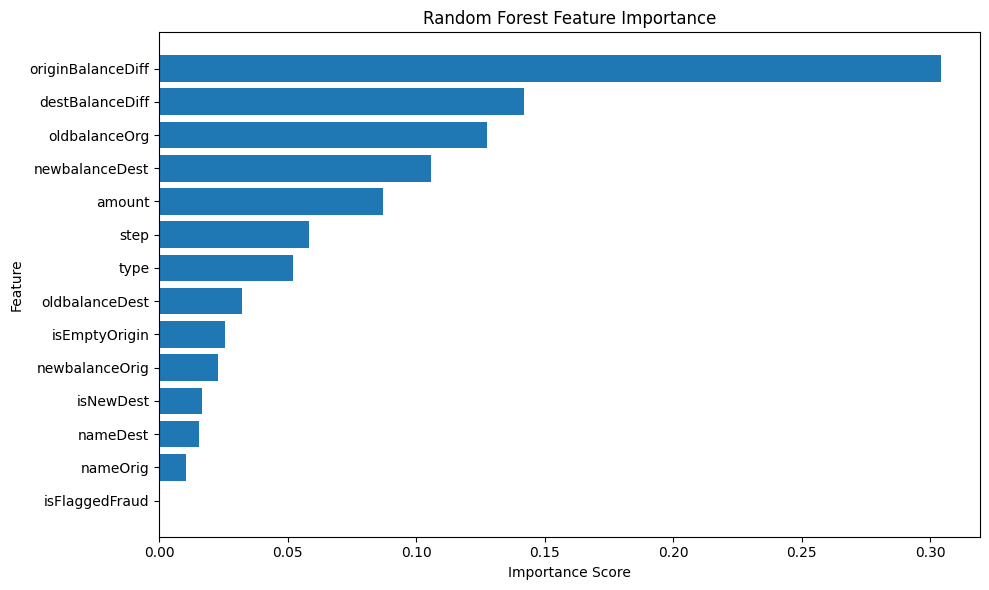

In [80]:
importance_table = importance_table.sort_values("Importance")

plt.figure(figsize=(10,6))
plt.barh(
    importance_table["Feature"],
    importance_table["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

In [81]:
# Remove features contributing less than 1%
threshold = 0.01

low_importance = importance_table[
    importance_table["Importance"] < threshold
]["Feature"].tolist()

print("Features to Remove:")
print(low_importance)

# Remove them
balanced_data = balanced_data.drop(columns=low_importance)

print("\nRemaining Features:")
print(balanced_data.columns.tolist())

Features to Remove:
['isFlaggedFraud']

Remaining Features:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'originBalanceDiff', 'destBalanceDiff', 'isNewDest', 'isEmptyOrigin']


# <b><span style='color:#1F3A5F'>3.9 |</span><span style='color:#1F3A5F'> Encode Categorical Variables</span></b>

In [82]:
from sklearn.preprocessing import LabelEncoder

# Make a copy
balanced_data = data.copy()

# Encode categorical variables
categorical_columns = balanced_data.select_dtypes(include=["object"]).columns

encoders = {}

for col in categorical_columns:
    encoder = LabelEncoder()
    balanced_data[col] = encoder.fit_transform(balanced_data[col])
    encoders[col] = encoder

In [83]:
import pandas as pd

overview_before = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Fraud Cases",
        "Non-Fraud Cases"
    ],
    "Value": [
        len(balanced_data),
        balanced_data.shape[1],
        (balanced_data["isFraud"] == 1).sum(),
        (balanced_data["isFraud"] == 0).sum()
    ]
})

display(
    overview_before.style
    .hide(axis="index")
    .set_caption("Table 1. Dataset Before Hybrid Sampling")
)

Metric,Value
Rows,643654
Columns,15
Fraud Cases,8213
Non-Fraud Cases,635441


In [84]:
from imblearn.over_sampling import BorderlineSMOTE

X = balanced_data.drop("isFraud", axis=1)
y = balanced_data["isFraud"]

borderline = BorderlineSMOTE(
    random_state=42,
    kind="borderline-1"
)

X_over, y_over = borderline.fit_resample(X, y)

In [85]:
from imblearn.under_sampling import TomekLinks

tomek = TomekLinks()

X_final, y_final = tomek.fit_resample(
    X_over,
    y_over
)

In [86]:
balanced_data = pd.concat(
    [
        X_final.reset_index(drop=True),
        y_final.reset_index(drop=True)
    ],
    axis=1
)

In [87]:
overview_after = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Fraud Cases",
        "Non-Fraud Cases"
    ],
    "Value": [
        len(balanced_data),
        balanced_data.shape[1],
        (balanced_data["isFraud"] == 1).sum(),
        (balanced_data["isFraud"] == 0).sum()
    ]
})

display(
    overview_after.style
    .hide(axis="index")
    .set_caption("Table 2. Dataset After Borderline-SMOTE + Tomek Links")
)

Metric,Value
Rows,1270738
Columns,15
Fraud Cases,635297
Non-Fraud Cases,635441


In [88]:
comparison = pd.DataFrame({
    "Original": y.value_counts().sort_index(),
    "Balanced": balanced_data["isFraud"].value_counts().sort_index()
})

comparison.index = ["Non-Fraud", "Fraud"]

comparison["Original (%)"] = (
    comparison["Original"] /
    comparison["Original"].sum() * 100
).round(2)

comparison["Balanced (%)"] = (
    comparison["Balanced"] /
    comparison["Balanced"].sum() * 100
).round(2)

display(
    comparison.style
    .set_caption(
        "Table 3. Class Distribution Before and After Hybrid Sampling"
    )
)

,Original,Balanced,Original (%),Balanced (%)
Non-Fraud,635441,635441,98.720000,50.010000
Fraud,8213,635297,1.280000,49.990000


In [89]:
balanced_data.to_csv(
    "balanced_dataset_BorderlineSMOTE_Tomek.csv",
    index=False
)

print("Balanced dataset saved successfully.")
print("Final Shape:", balanced_data.shape)

Balanced dataset saved successfully.
Final Shape: (1270738, 15)


# <b><span style='color:#1F3A5F'>3.10 |</span><span style='color:#1F3A5F'> Separate Features and Target</span></b>

In [90]:
X = balanced_data.drop("isFraud", axis=1)

y = balanced_data["isFraud"]

# <b><span style='color:#1F3A5F'>3.11 |</span><span style='color:#1F3A5F'> Train-Test Split</span></b>

In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)


Training Shape: (1016590, 14)
Testing Shape : (254148, 14)


# <b><span style='color:#1F3A5F'>3.12 |</span><span style='color:#1F3A5F'> Feature Scaling</span></b>

In [92]:
print(X_train.columns.tolist())

['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'originBalanceDiff', 'destBalanceDiff', 'isNewDest', 'isEmptyOrigin']


In [93]:
scaler = StandardScaler()

numeric_columns = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "originBalanceDiff",
    "destBalanceDiff"
]

X_train[numeric_columns] = scaler.fit_transform(
    X_train[numeric_columns]
)

X_test[numeric_columns] = scaler.transform(
    X_test[numeric_columns]
)

print("\nPreprocessing Complete!")


Preprocessing Complete!


# <p style="background-color: #1F3A5F; font-family:calibri; color:white; font-size:140%; font-family:Verdana; text-align:center; border-radius:15px 50px;">4.| Model Development and Selection</p>

# <b><span style='color:#1F3A5F'>4.1 |</span><span style='color:#1F3A5F'> Random Forest</span></b>

In [94]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

print("="*60)
print("Random Forest")
print("="*60)

print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test,y_pred))
print("F1-Score :", f1_score(y_test,y_pred))
print("ROC-AUC  :", roc_auc_score(y_test,y_prob))

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

Random Forest
Accuracy : 0.9991894486677054
Precision: 0.998553709264121
Recall   : 0.9998268534550606
F1-Score : 0.9991898758071747
ROC-AUC  : 0.999987472845591
[[126904    184]
 [    22 127038]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    127088
           1       1.00      1.00      1.00    127060

    accuracy                           1.00    254148
   macro avg       1.00      1.00      1.00    254148
weighted avg       1.00      1.00      1.00    254148



In [95]:
rf_acc = accuracy_score(y_test, y_pred)
rf_pre = precision_score(y_test, y_pred)
rf_rec = recall_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_auc = roc_auc_score(y_test, y_prob)

# <b><span style='color:#1F3A5F'>4.2 |</span><span style='color:#1F3A5F'> Logistic Regression</span></b>

In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)

# Train Model
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:,1]

# Evaluation
print("="*60)
print("Logistic Regression")
print("="*60)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Logistic Regression
Accuracy : 0.9476092670412516
Precision: 0.9485319053289905
Recall   : 0.946568550291201
F1-Score : 0.9475492107761456
ROC-AUC  : 0.9848832445812709

Confusion Matrix
[[120562   6526]
 [  6789 120271]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.95      0.95    127088
           1       0.95      0.95      0.95    127060

    accuracy                           0.95    254148
   macro avg       0.95      0.95      0.95    254148
weighted avg       0.95      0.95      0.95    254148



In [97]:
# Predictions
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

# Save metrics
lr_acc = accuracy_score(y_test, y_pred)
lr_pre = precision_score(y_test, y_pred)
lr_rec = recall_score(y_test, y_pred)
lr_f1 = f1_score(y_test, y_pred)
lr_auc = roc_auc_score(y_test, y_prob)

# Print metrics
print("Accuracy :", lr_acc)
print("Precision:", lr_pre)
print("Recall   :", lr_rec)
print("F1-Score :", lr_f1)
print("ROC-AUC  :", lr_auc)

Accuracy : 0.9476092670412516
Precision: 0.9485319053289905
Recall   : 0.946568550291201
F1-Score : 0.9475492107761456
ROC-AUC  : 0.9848832445812709


# <b><span style='color:#1F3A5F'>4.3 |</span><span style='color:#1F3A5F'> Light GBM</span></b>

In [98]:
from lightgbm import LGBMClassifier
from sklearn.metrics import *

lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

lgbm.fit(X_train, y_train)

y_pred = lgbm.predict(X_test)
y_prob = lgbm.predict_proba(X_test)[:,1]

print("="*60)
print("LightGBM")
print("="*60)

print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test,y_pred))
print("F1-Score :", f1_score(y_test,y_pred))
print("ROC-AUC  :", roc_auc_score(y_test,y_prob))

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[LightGBM] [Info] Number of positive: 508237, number of negative: 508353
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.045200 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2561
[LightGBM] [Info] Number of data points in the train set: 1016590, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499943 -> initscore=-0.000228
[LightGBM] [Info] Start training from score -0.000228
LightGBM
Accuracy : 0.998469395785133
Precision: 0.997361456852752
Recall   : 0.999582874232646
F1-Score : 0.9984709299811716
ROC-AUC  : 0.9994320755289849
[[126752    336]
 [    53 127007]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    127088
           1       1.00      1.00      1.00    127060

    accuracy                           1.00    254148
   macro avg       1.00      

In [99]:
lgbm_acc = accuracy_score(y_test, y_pred)
lgbm_pre = precision_score(y_test, y_pred)
lgbm_rec = recall_score(y_test, y_pred)
lgbm_f1 = f1_score(y_test, y_pred)
lgbm_auc = roc_auc_score(y_test, y_prob)

# <b><span style='color:#1F3A5F'>4.4 |</span><span style='color:#1F3A5F'> eXtreme Gradient Boosting (XGBoost)</span></b>

In [100]:
from xgboost import XGBClassifier
from sklearn.metrics import *

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

print("="*60)
print("XGBoost")
print("="*60)

print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test,y_pred))
print("F1-Score :", f1_score(y_test,y_pred))
print("ROC-AUC  :", roc_auc_score(y_test,y_prob))

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

XGBoost
Accuracy : 0.9985166123675968
Precision: 0.9972445735369156
Recall   : 0.9997953722650716
F1-Score : 0.9985183438464108
ROC-AUC  : 0.9999258160922821
[[126737    351]
 [    26 127034]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    127088
           1       1.00      1.00      1.00    127060

    accuracy                           1.00    254148
   macro avg       1.00      1.00      1.00    254148
weighted avg       1.00      1.00      1.00    254148



In [101]:
xgb_acc = accuracy_score(y_test, y_pred)
xgb_pre = precision_score(y_test, y_pred)
xgb_rec = recall_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_auc = roc_auc_score(y_test, y_prob)

# <b><span style='color:#1F3A5F'>4.5 |</span><span style='color:#1F3A5F'> CatBoost</span></b>

In [102]:
from catboost import CatBoostClassifier
from sklearn.metrics import *

cat = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=False
)

cat.fit(X_train, y_train)

y_pred = cat.predict(X_test)
y_prob = cat.predict_proba(X_test)[:,1]

print("="*60)
print("CatBoost")
print("="*60)

print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test,y_pred))
print("F1-Score :", f1_score(y_test,y_pred))
print("ROC-AUC  :", roc_auc_score(y_test,y_prob))

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

CatBoost
Accuracy : 0.9976037584399641
Precision: 0.9955481357818586
Recall   : 0.9996773178026129
F1-Score : 0.997608454056007
ROC-AUC  : 0.9998516350951774
[[126520    568]
 [    41 127019]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    127088
           1       1.00      1.00      1.00    127060

    accuracy                           1.00    254148
   macro avg       1.00      1.00      1.00    254148
weighted avg       1.00      1.00      1.00    254148



In [103]:
cat_acc = accuracy_score(y_test, y_pred)
cat_pre = precision_score(y_test, y_pred)
cat_rec = recall_score(y_test, y_pred)
cat_f1 = f1_score(y_test, y_pred)
cat_auc = roc_auc_score(y_test, y_prob)

# <p style="background-color: #1F3A5F; font-family:calibri; color:white; font-size:140%; font-family:Verdana; text-align:center; border-radius:15px 50px;">6.| Performance Overview</p>

In [104]:
import pandas as pd

# ==========================================================
# MODEL PERFORMANCE COMPARISON
# ==========================================================

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],
    "Accuracy": [lr_acc, rf_acc, xgb_acc, lgbm_acc, cat_acc],
    "Precision": [lr_pre, rf_pre, xgb_pre, lgbm_pre, cat_pre],
    "Recall": [lr_rec, rf_rec, xgb_rec, lgbm_rec, cat_rec],
    "F1-Score": [lr_f1, rf_f1, xgb_f1, lgbm_f1, cat_f1],
    "ROC-AUC": [lr_auc, rf_auc, xgb_auc, lgbm_auc, cat_auc]
})

# Round values
results = results.round(4)

# Rank models based on ROC-AUC (or F1-Score if preferred)
results = results.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

results.insert(0, "Rank", range(1, len(results)+1))

display(
    results.style
        .hide(axis="index")
        .set_caption("Table 1. Performance Comparison of Machine Learning Models")
        .highlight_max(
            subset=["Accuracy","Precision","Recall","F1-Score","ROC-AUC"],
            color="#90EE90"
        )
        .format({
            "Accuracy":"{:.4f}",
            "Precision":"{:.4f}",
            "Recall":"{:.4f}",
            "F1-Score":"{:.4f}",
            "ROC-AUC":"{:.4f}"
        })
)

Rank,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Random Forest,0.9992,0.9986,0.9998,0.9992,1.0000
2,CatBoost,0.9976,0.9955,0.9997,0.9976,0.9999
3,XGBoost,0.9985,0.9972,0.9998,0.9985,0.9999
4,LightGBM,0.9985,0.9974,0.9996,0.9985,0.9994
5,Logistic Regression,0.9476,0.9485,0.9466,0.9475,0.9849


# <b><span style='color:#1F3A5F'>6.1 |</span><span style='color:#1F3A5F'> Accuracy Comparison</span></b>

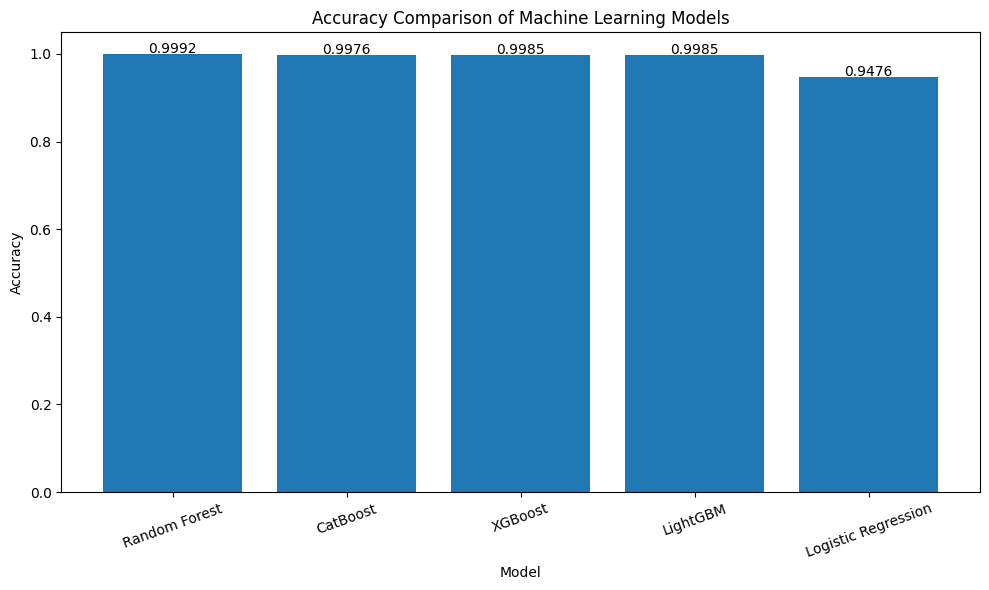

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)

for i, v in enumerate(results["Accuracy"]):
    plt.text(i, v + 0.002, f"{v:.4f}", ha="center")

plt.tight_layout()
plt.show()

# <b><span style='color:#1F3A5F'>6.2 |</span><span style='color:#1F3A5F'> Precision, Recall and F1-Score Comparison</span></b>

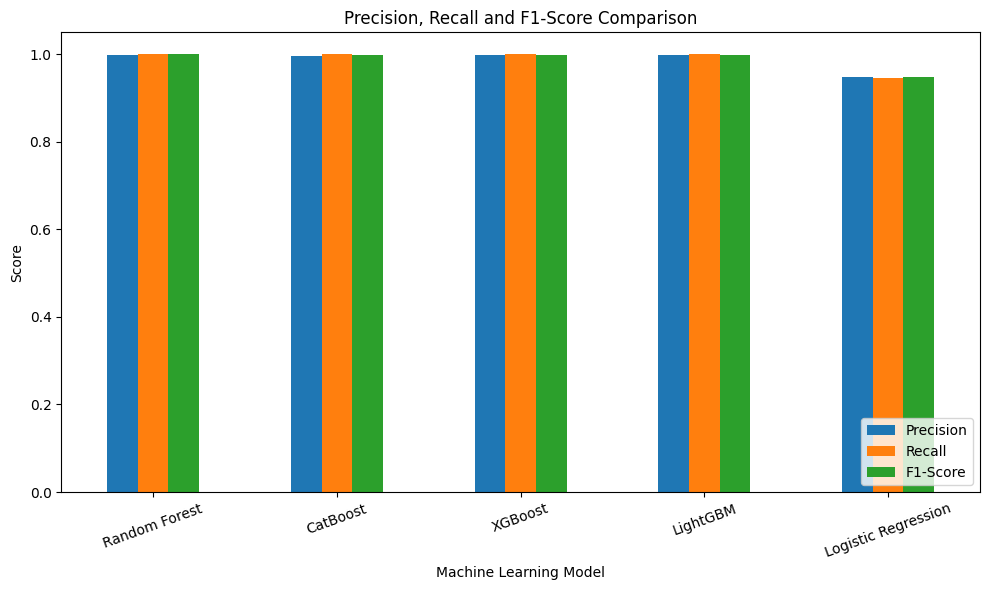

In [106]:
metrics = ["Precision", "Recall", "F1-Score"]

results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Precision, Recall and F1-Score Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")

plt.xticks(rotation=20)

plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

# <b><span style='color:#1F3A5F'>6.3 |</span><span style='color:#1F3A5F'> ROC-AUC Comparison</span></b>

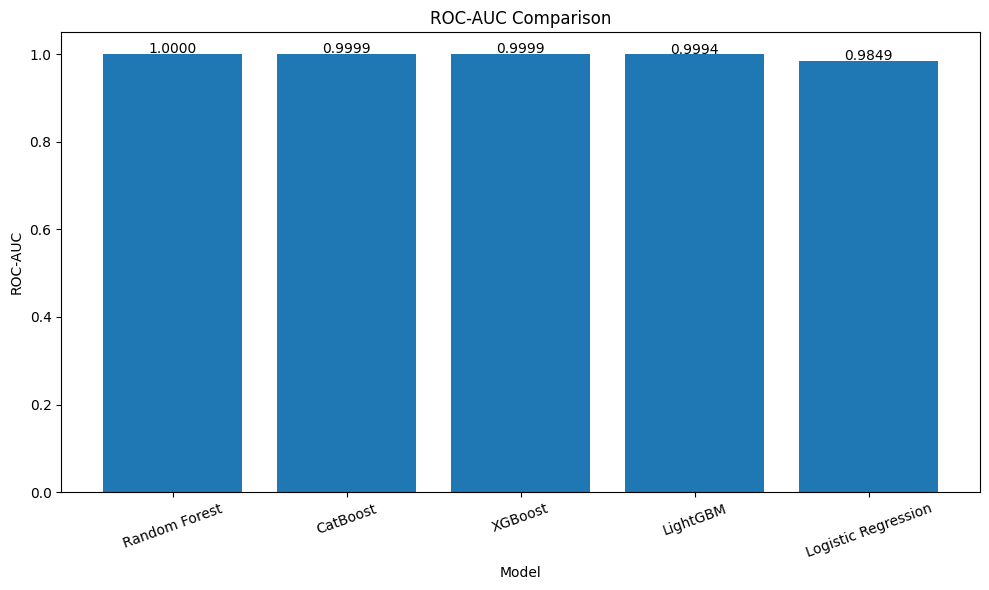

In [107]:
plt.figure(figsize=(10,6))

plt.bar(results["Model"], results["ROC-AUC"])

plt.title("ROC-AUC Comparison")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")

plt.xticks(rotation=20)

for i, v in enumerate(results["ROC-AUC"]):
    plt.text(i, v + 0.002, f"{v:.4f}", ha="center")

plt.tight_layout()
plt.show()

# <b><span style='color:#1F3A5F'>6.4 |</span><span style='color:#1F3A5F'> Overall Model Performance (Grouped Bar Chart)</span></b>

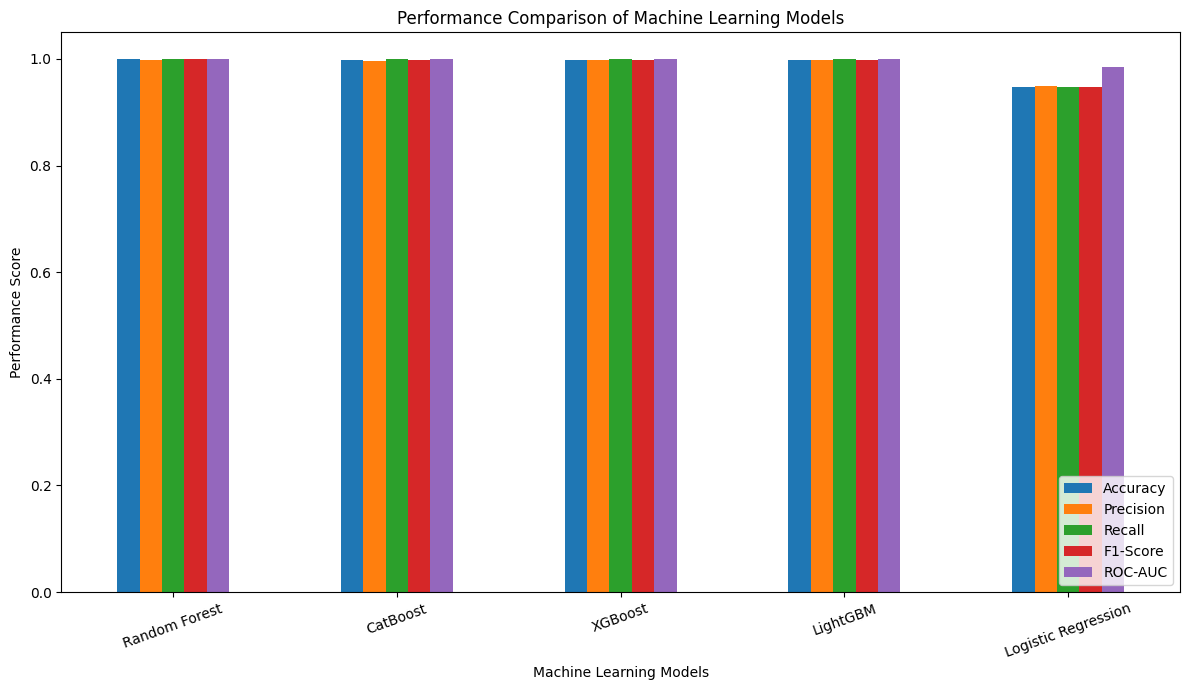

In [108]:
metrics = ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]

results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12,7)
)

plt.title("Performance Comparison of Machine Learning Models")
plt.xlabel("Machine Learning Models")
plt.ylabel("Performance Score")

plt.ylim(0,1.05)

plt.xticks(rotation=20)

plt.legend(loc="lower right")

plt.tight_layout()
# ==========================================================
# SAVE FIGURE
# ==========================================================
plt.savefig(
    "/kaggle/working/model_performance_comparison.png",
    dpi=300,                 # High quality for dissertation
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

# <b><span style='color:#1F3A5F'>6.5 |</span><span style='color:#1F3A5F'> Radar Chart</span></b>

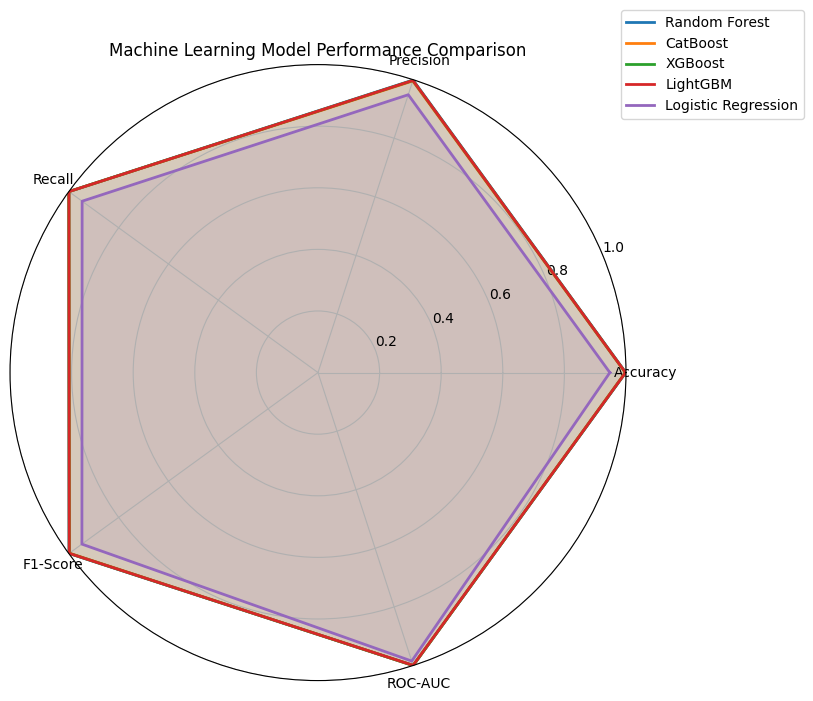

In [109]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]

labels = np.array(metrics)
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
angles = np.concatenate((angles,[angles[0]]))

plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

for _, row in results.iterrows():

    values = row[metrics].tolist()
    values += values[:1]

    ax.plot(angles, values, linewidth=2, label=row["Model"])
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

ax.set_ylim(0,1)

plt.title("Machine Learning Model Performance Comparison")

plt.legend(loc='upper right', bbox_to_anchor=(1.3,1.1))

plt.show()

# <b><span style='color:#1F3A5F'>6.6 |</span><span style='color:#1F3A5F'> Confusion Matrix for Each Model</span></b>

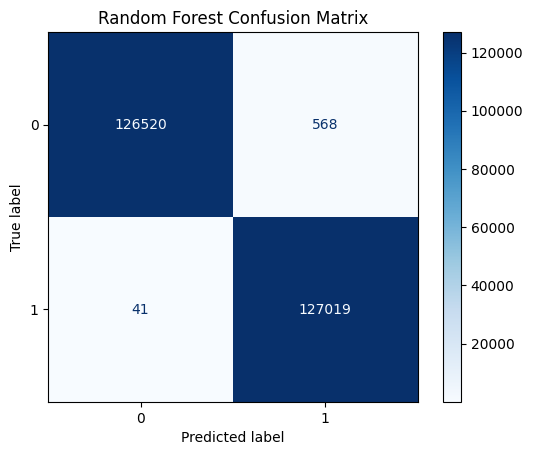

In [110]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

# <b><span style='color:#1F3A5F'>6.7 |</span><span style='color:#1F3A5F'> ROC Curves (Best Figure for Fraud Detection)</span></b>

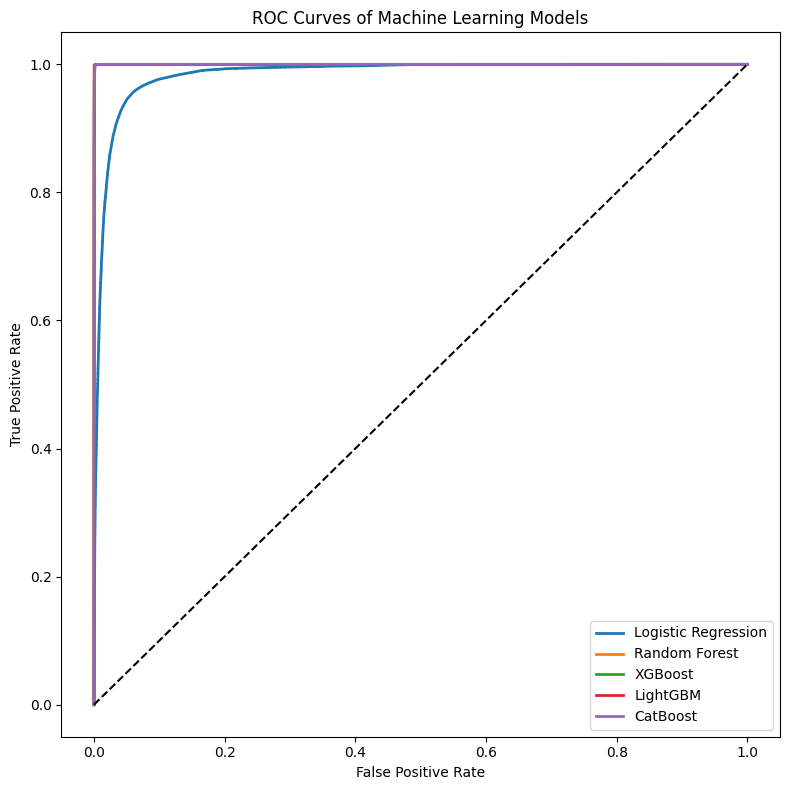

In [111]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,8))

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb,
    "LightGBM": lgbm,
    "CatBoost": cat
}

for name, model in models.items():

    probs = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, probs)

    plt.plot(fpr, tpr, linewidth=2, label=name)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curves of Machine Learning Models")

plt.legend()

plt.tight_layout()

plt.show()

# <p style="background-color: #1F3A5F; font-family:calibri; color:white; font-size:140%; font-family:Verdana; text-align:center; border-radius:15px 50px;">7.| Explainable Artificial Intelligence</p>

# <b><span style='color:#1F3A5F'>7.1 |</span><span style='color:#1F3A5F'> LIME (Local Interpretable Model-agnostic Explanations)</span></b>

In [112]:
!pip install lime

In [113]:
# ==========================================================
# LIME EXPLANATION FOR LIGHTGBM
# ==========================================================

from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt

# Create explainer
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=["Non-Fraud", "Fraud"],
    mode="classification"
)

# Choose an instance from the test set
instance = 0

# Generate explanation
explanation = explainer.explain_instance(
    X_test.iloc[instance].values,
    lgbm.predict_proba,
    num_features=10
)

# Display explanation
explanation.show_in_notebook(show_table=True)

# Save explanation
explanation.save_to_file("LIME_LightGBM.html")

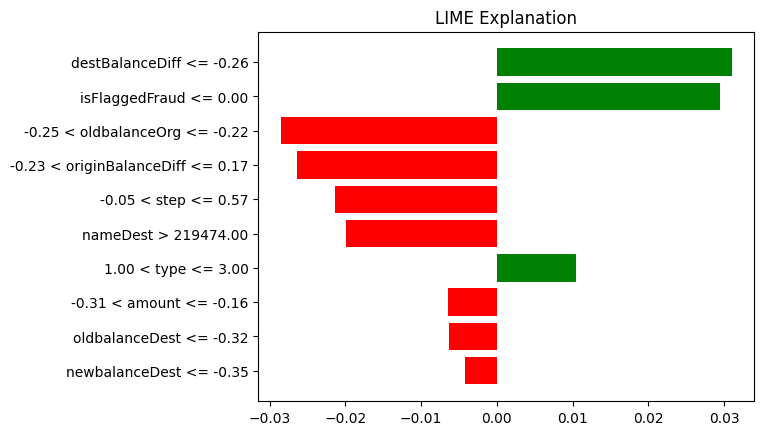

In [114]:
fig = explanation.as_pyplot_figure()

plt.title("LIME Explanation")

plt.show()

In [115]:
# Choose an instance from the test set
instance = 2

# Generate explanation
explanation = explainer.explain_instance(
    X_test.iloc[instance].values,
    lgbm.predict_proba,
    num_features=10
)

# Display explanation
explanation.show_in_notebook(show_table=True)

# Save explanation
explanation.save_to_file("LIME_LightGBM.html")

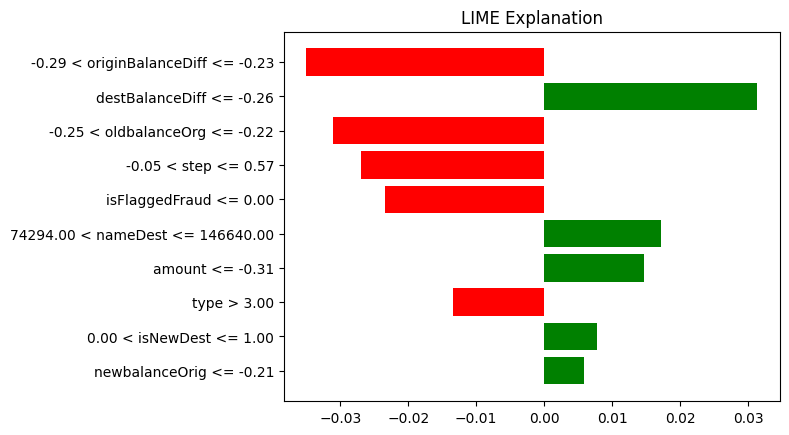

In [116]:
fig = explanation.as_pyplot_figure()

plt.title("LIME Explanation")

plt.show()

# <b><span style='color:#1F3A5F'>7.2 |</span><span style='color:#1F3A5F'> SHAP (SHapley Additive exPlanations)</span></b>

In [117]:
!pip install shap

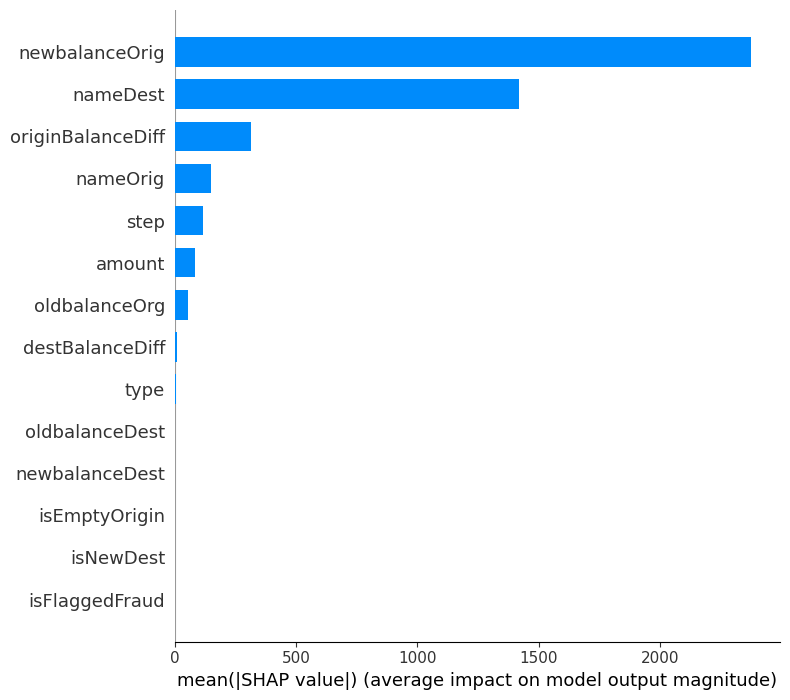

In [118]:
# ==========================================================
# SHAP EXPLANATION FOR LIGHTGBM
# ==========================================================

import shap

# Initialize JS visualization
shap.initjs()

# Create Tree Explainer
explainer = shap.TreeExplainer(lgbm)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# Summary Plot
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

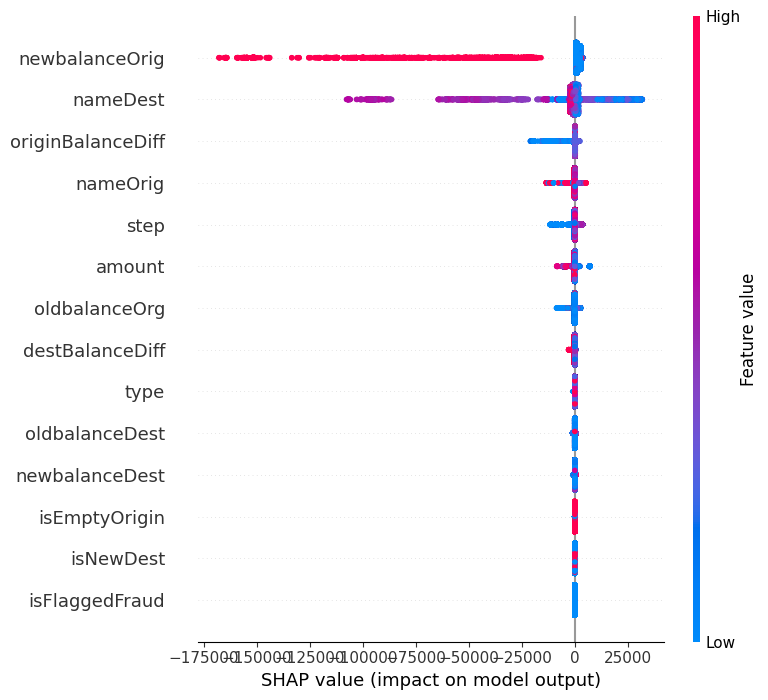

In [119]:
shap.summary_plot(
    shap_values,
    X_test
)

In [120]:
instance = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[instance],
    X_test.iloc[instance]
)

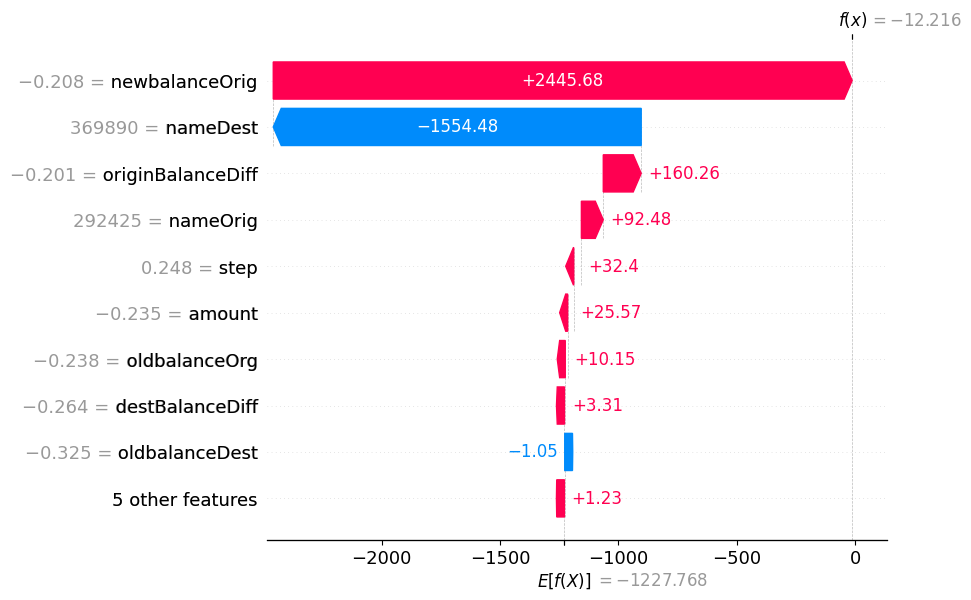

In [121]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[instance],
        base_values=explainer.expected_value,
        data=X_test.iloc[instance],
        feature_names=X_test.columns
    )
)

In [122]:
instance = 2

shap.force_plot(
    explainer.expected_value,
    shap_values[instance],
    X_test.iloc[instance]
)

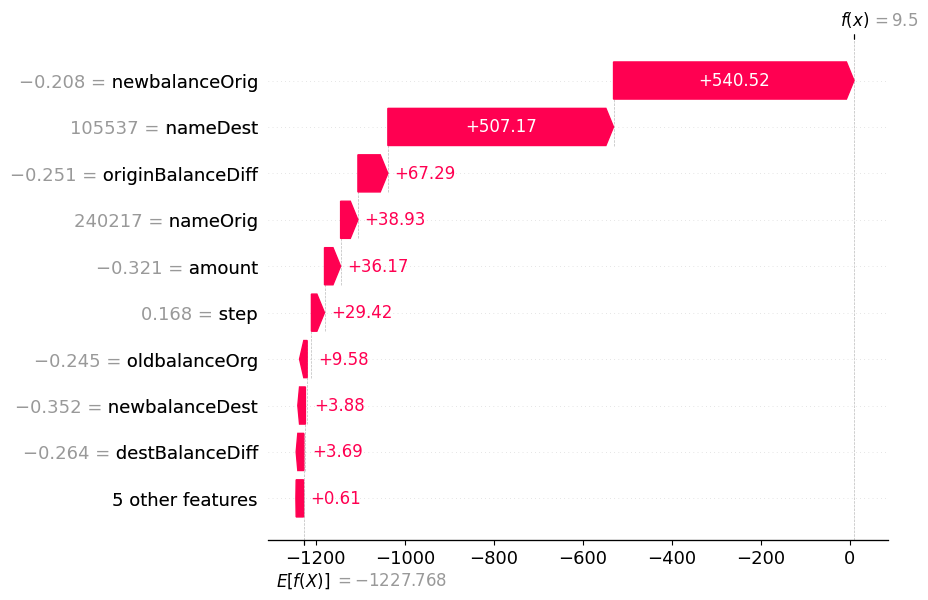

In [123]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[instance],
        base_values=explainer.expected_value,
        data=X_test.iloc[instance],
        feature_names=X_test.columns
    )
)

# <b><span style='color:#1F3A5F'>7.3 |</span><span style='color:#1F3A5F'> Counterfactual Explanations</span></b>


In [124]:
!pip install dice-ml

In [125]:
# ==========================================================
# COUNTERFACTUAL EXPLANATIONS
# ==========================================================

import dice_ml

# Prepare Data
dice_data = dice_ml.Data(
    dataframe=pd.concat([X_train, y_train], axis=1),
    continuous_features=X_train.columns.tolist(),
    outcome_name="isFraud"
)

# Build Model
dice_model = dice_ml.Model(
    model=lgbm,
    backend="sklearn"
)

# Create DiCE
exp = dice_ml.Dice(
    dice_data,
    dice_model,
    method="random"
)

# Select transaction
query = X_test.iloc[[0]]

# Generate Counterfactuals
counterfactuals = exp.generate_counterfactuals(
    query,
    total_CFs=3,
    desired_class="opposite"
)

# Display
counterfactuals.visualize_as_dataframe()

100%|██████████| 1/1 [00:08<00:00,  8.33s/it]

Query instance (original outcome : 0)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFlaggedFraud,originBalanceDiff,destBalanceDiff,isNewDest,isEmptyOrigin,isFraud
0,0.24826,3,-0.235491,292425,-0.237871,-0.207663,369890,-0.32485,-0.351953,0,-0.201124,-0.263967,1,1,0



Diverse Counterfactual set (new outcome: 1)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFlaggedFraud,originBalanceDiff,destBalanceDiff,isNewDest,isEmptyOrigin,isFraud
0,0.24826,3,-0.235491,292425,-0.237871,-0.207663,64559,-0.32485,-0.351953,0,-0.201124,-0.263967,1,1,1
1,0.24826,3,-0.235491,292425,11.420165,-0.207663,369890,-0.32485,-0.351953,0,-0.201124,-0.263967,1,1,1
2,0.24826,3,-0.235491,292425,-0.237871,-0.207663,102023,-0.32485,-0.351953,0,-0.201124,-0.263967,1,1,1


In [126]:
counterfactuals.cf_examples_list[0].final_cfs_df.to_csv(
    "LightGBM_Counterfactuals.csv",
    index=False
)

# <p style="background-color: #1F3A5F; font-family:calibri; color:white; font-size:140%; font-family:Verdana; text-align:center; border-radius:15px 50px;">8.| Pickle and Save the model.  </p>

In [127]:
# ==========================================================
# SAVE THE BEST MODEL USING PICKLE
# ==========================================================

import pickle

best_model = rf

# File name
model_filename = "best_fraud_detection_model.pkl"

# Save the model
with open(model_filename, "wb") as file:
    pickle.dump(best_model, file)

print(f"Model successfully saved as '{model_filename}'")

Model successfully saved as 'best_fraud_detection_model.pkl'


In [128]:
best_model = lr

# File name
model_filename = "fraud_detection_model.pkl"

# Save the model
with open(model_filename, "wb") as file:
    pickle.dump(best_model, file)

print(f"Model successfully saved as '{model_filename}'")

Model successfully saved as 'fraud_detection_model.pkl'
